<a href="https://colab.research.google.com/github/alberto-saldana-data/test-projects/blob/main/S5_ladb_mobility_economy_project_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Perfecto en esta sección! Las cuatro librerías requeridas (`pandas`, `numpy`, `seaborn`, `matplotlib.pyplot`) están importadas correctamente y sin errores.

💡 **Tip profesional:** En proyectos colaborativos es útil agregar una celda inicial con las versiones de las librerías (`pd.__version__`, etc.) para facilitar la reproducibilidad del análisis en otros entornos.

</div>


In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.

<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Ambos archivos se cargan correctamente con `pd.read_csv()` en las variables `traffic` y `eco`, tal como se pedía. Mostraste las primeras 5 filas de cada DataFrame con `.head()`, y en el paso 2.1 complementaste con `.info()` y `.tail()` para profundizar en la exploración. Eso es exactamente el orden correcto de trabajo. ✅

</div>


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:
# Examinar la estructura de traffic
traffic.info()
traffic.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
1004461,ZAF,pretoria,2024-10-01 10:01:30.000,85.0,21.0,9.7,29.0,16.0,2024-09-24 10:16:30.001,13.690491,13.287302,0.403189
1004462,ZAF,pretoria,2024-10-01 09:01:30.000,68.1,20.0,6.7,23.0,15.0,2024-09-24 09:46:30.000,13.387203,12.983558,0.403646
1004463,ZAF,pretoria,2024-10-01 08:46:30.000,67.7,20.0,6.6,22.0,13.0,2024-09-24 08:46:30.000,13.311492,12.898624,0.412867


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo 'object' en el dataset original
- Se realizará la conversión de dichas columnas a tipo 'Datetime' para la integración correcta del dataset final.
- Sin datos ausentes.

In [ ]:
# Examinar la estructura de eco
eco.info()
eco.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
27,2024,mexico-city,Mexico,"21.111,00",3.2%,"22,30","22,10"
28,2024,lima,Peru,"13.472,00",6.5%,"19,70","11,20"
29,2024,montevideo,Uruguay,"26.176,00",8.4%,"11,20","1,80"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, y `Population (M)` son de tipo 'object' en el dataset original.
- Se realizará la conversión de dichas columnas a tipo de dato 'float' para la integración correcta en el dataset final.
- Sin datos ausentes.

<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente exploración inicial. Identificaste correctamente en ambos DataFrames cuáles columnas requieren conversión de tipo y por qué, y confirmaste la ausencia de valores nulos. Tus observaciones en Markdown son claras y muestran comprensión real de la estructura de los datos antes de tocarlos. ✅

</div>

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_in_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10_kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10_kms_mins',
    'MinsDelay': 'mins_delay'
})

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    'Year': 'year',
    'City':'city',
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_percent',
    'PM2.5 (μg/m³)': 'pm2_5_ug_m3',
    'Population (M)': 'population_m'
})

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_percent',
       'pm2_5_ug_m3', 'population_m'],
      dtype='object')

<div class="alert alert-block alert-warning">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Renombraste todas las columnas de ambos datasets a formato `snake_case`, lo cual es fundamental para evitar errores en el merge y en el análisis posterior. ✅

Sin embargo, hay **inconsistencias menores en los nombres** respecto a la convención usada en la solución de referencia. Te las comparto para que las tengas en cuenta en futuros proyectos:

| Tu nombre | Nombre de referencia | Nota |
|---|---|---|
| `jams_length_in_kms` | `jams_length_kms` | Más verboso, pero funcional |
| `travel_time_live_per_10_kms_mins` | `travel_time_live_per_10kms_mins` | El guion bajo extra no genera errores |
| `travel_time_historic_per_10_kms_mins` | `travel_time_hist_per_10kms_mins` | Ídem |
| `unemployment_percent` | `unemployment_pct` | Ambos son válidos |
| `pm2_5_ug_m3` | `pm25` | `pm25` es más conciso |

Estas diferencias **no generan errores** siempre que uses tus propios nombres de forma consistente en el resto del notebook (y así lo hiciste 👏). En equipos de trabajo, lo ideal es acordar una convención de nombres y documentarla desde el inicio.

</div>


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')


# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   country                               1004464 non-null  object        
 1   city                                  1004464 non-null  object        
 2   update_time_utc                       1004464 non-null  datetime64[ns]
 3   jams_delay                            1004464 non-null  float64       
 4   traffic_index_live                    1004464 non-null  float64       
 5   jams_length_in_kms                    1004464 non-null  float64       
 6   jams_count                            1004464 non-null  float64       
 7   traffic_index_week_ago                1004464 non-null  float64       
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins      1004464 

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
# eco['city_gdp_capita'] = ....astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .astype(str)
    .str.replace('.', '')
    .str.replace(',', '.')
    .astype(float)
)

# eco['unemployment_pct'] = ...
eco['unemployment_percent'] = (
    eco['unemployment_percent']
    .astype(str)
    .str.replace('%', '')
    .str.replace(',', '.')
    .astype(float)
)

# eco['population_m'] = ...
eco['population_m'] = (
    eco['population_m']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
# eco['population'] = ...
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  30 non-null     int64  
 1   city                  30 non-null     object 
 2   country               30 non-null     object 
 3   city_gdp_capita       30 non-null     float64
 4   unemployment_percent  30 non-null     float64
 5   pm2_5_ug_m3           30 non-null     object 
 6   population_m          30 non-null     float64
 7   population            30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_percent,pm2_5_ug_m3,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Excelente trabajo en la limpieza numérica! La cadena encadenada de `.str.replace()` para eliminar separadores de miles, el símbolo `%` y las comas decimales estuvo muy bien ejecutada, y la creación de `population = population_m * 1_000_000` es correcta. ✅

El uso de `errors='coerce'` en `pd.to_datetime()` es una práctica sólida para hacer la conversión a prueba de errores. 👏

</div>

<div class="alert alert-block alert-warning">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Una pequeña recomendación para hacer el código más robusto: agrega `regex=False` dentro de los `.str.replace()`. El punto (`.`) es un metacarácter en expresiones regulares, lo que puede generar comportamientos inesperados en algunos entornos:

```python
# Más robusto:
.str.replace('.', '', regex=False)
.str.replace(',', '.', regex=False)
```

No es un error en este caso, pero es una buena práctica que te ayudará a evitar bugs difíciles de detectar en datasets más grandes o con caracteres especiales.

</div>



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
# traffic['year'] = ...
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
# traffic_2024 = traffic[...].copy()
traffic_2024 = traffic[traffic['year'] == 2024].copy()

# eco_2024 = ...
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_percent,pm2_5_ug_m3,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Muy bien ejecutado! Extrajiste el año con `.dt.year` de forma correcta, filtraste `traffic_2024` y `eco_2024` con la condición booleana apropiada, y usaste `.copy()` en ambos DataFrames. Ese detalle de `.copy()` es importante para evitar el `SettingWithCopyWarning` de pandas y proteger el dataset original de modificaciones accidentales. 🌟

</div>

<div class="alert alert-block alert-warning">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Te recomiendo agregar una validación explícita después del filtrado. Son solo un par de líneas y te dan certeza de que el filtro funcionó como esperabas:

```python
print("Años únicos en traffic_2024:", traffic_2024['year'].unique())
print("Filas en traffic_2024:", traffic_2024.shape[0])
print("Años únicos en eco_2024:", eco_2024['year'].unique())
print("Filas en eco_2024:", eco_2024.shape[0])
```

En proyectos reales, estas validaciones intermedias son las que permiten detectar errores antes de que se propaguen a las etapas siguientes.

</div>



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'], as_index=False)
    [['jams_delay',
      'traffic_index_live',
      'jams_length_in_kms',
      'jams_count',
      'mins_delay',
      'travel_time_live_per_10_kms_mins',
      'travel_time_historic_per_10_kms_mins']]
    .mean()
)

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [ ]:
# tu código aquí
traffic_city_year_2024.sort_values(['jams_delay'],ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es 'mexico-city', seguida por 'tokyo'

<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡La agregación está muy bien hecha! Agrupaste por `city`, `country` y `year` usando `as_index=False`, calculaste el promedio de las 7 métricas de tráfico relevantes y mostraste el resultado con `.head()`. Todo correcto. ✅

Además, la reflexión sobre Ciudad de México siendo la más congestionada muestra que conectas los resultados con la realidad, que es exactamente lo que se espera de un analista de datos.

</div>

<div class="alert alert-block alert-warning">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Como alternativa más explícita y flexible, considera usar `.agg()` en lugar de seleccionar columnas antes del `.mean()`. La ventaja es que en el futuro puedes aplicar funciones distintas a cada columna (por ejemplo, `sum` para conteos y `mean` para promedios) sin reestructurar el código:

```python
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'])
    .agg({
        'jams_delay': 'mean',
        'traffic_index_live': 'mean',
        'mins_delay': 'mean',
        # ...
    })
    .reset_index()
)
```

Tu solución actual es completamente válida; esto es solo un tip de estilo para proyectos más avanzados.

</div>



---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10_kms_mins','travel_time_historic_per_10_kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_percent','pm2_5_ug_m3','population']

# Usar .copy() para crear los dos nuevos datasets reducidos

# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
traffic_2024_small = traffic_city_year_2024[left_cols].copy()

# eco_2024_small = ...
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,city_gdp_capita,unemployment_percent,pm2_5_ug_m3,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡El merge está correcto y bien estructurado! Seleccionaste columnas relevantes de ambos DataFrames, usaste `.copy()` al crear los subconjuntos, y ejecutaste `pd.merge(..., on=['city', 'year'], how='inner')` que es exactamente lo que se pedía. ✅

</div>

<div class="alert alert-block alert-warning">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Dos recomendaciones para fortalecer esta sección:

**1. Validación post-merge:** Faltó verificar la estructura y posibles duplicados después de la unión. Agrega estas líneas:

```python
print("Shape del merged:", merged.shape)
print("¿Hay duplicados?", merged.duplicated().sum())
merged.info()
```

**2. Documenta la decisión del join:** Es buena práctica agregar un comentario o celda Markdown explicando por qué elegiste `inner`. Por ejemplo: *"Usamos inner join para mantener solo las ciudades con datos disponibles en ambos datasets durante 2024."* Esto hace el notebook más legible para cualquier persona que lo revise.

</div>


## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.

- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.


**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

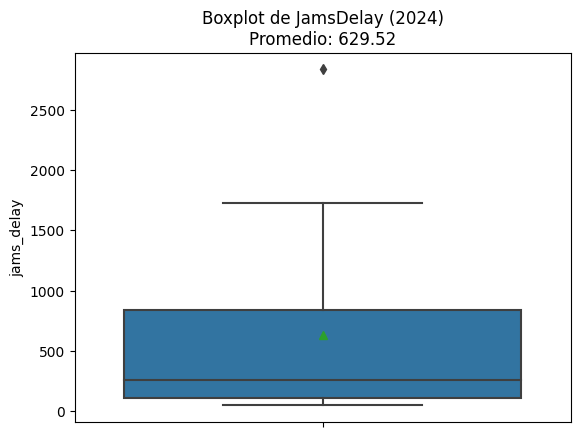

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot(y=merged['jams_delay'], showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()




<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Muy bien: incluiste `showmeans=True` y el valor del promedio en el título, lo cual añade información analítica valiosa al gráfico. ✅

</div>

<div class="alert alert-block alert-warning">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Usaste `y=merged['jams_delay']` (boxplot vertical), mientras que la convención más habitual para un solo grupo es `x=` (horizontal), ya que permite leer mejor las etiquetas del eje. Prueba con:

```python
sns.boxplot(x=merged['jams_delay'], showmeans=True)
```

No es un error, solo una preferencia de estilo visual. 😊

</div>


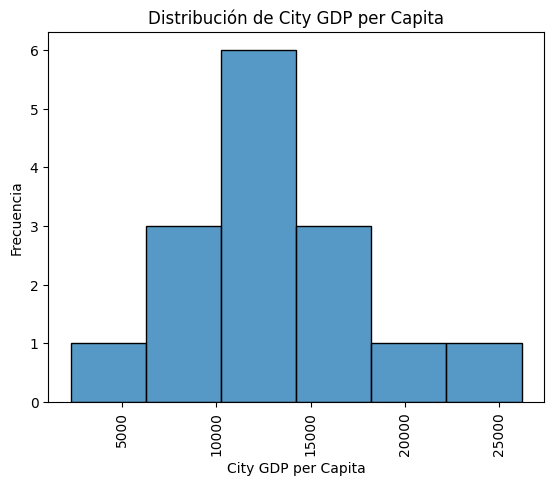

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(merged['city_gdp_capita'])

plt.title('Distribución de City GDP per Capita')
plt.xlabel('City GDP per Capita')
plt.ylabel('Frecuencia')

plt.xticks(rotation=90)
plt.show()


<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Histograma correcto y bien etiquetado! Título, etiquetas en ambos ejes y rotación de etiquetas del eje X. Las observaciones sobre la concentración del PIB en el rango 10,000–15,000 están bien identificadas. ✅

</div>


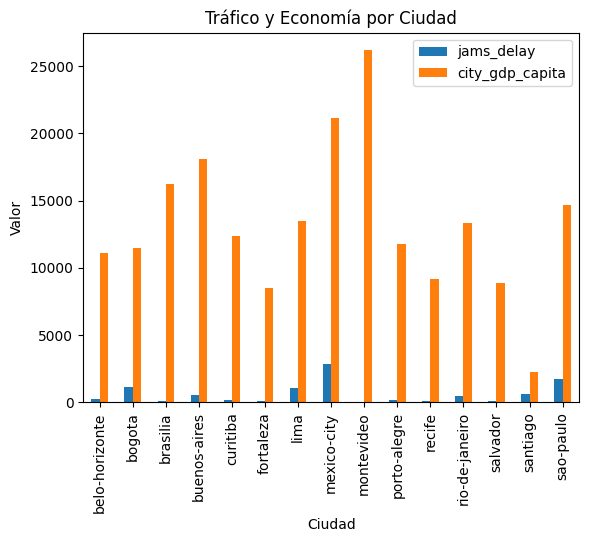

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])

merged.plot(
    x='city',
    y=['jams_delay', 'city_gdp_capita'],
    kind='bar'
)

plt.title('Tráfico y Economía por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Valor')

plt.xticks(rotation=90)

plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

<div class="alert alert-block alert-warning">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El gráfico comparativo está presente y muestra ambas variables por ciudad, lo cual es correcto. Sin embargo, hay un punto importante a mejorar:

**Escalas muy diferentes:** `jams_delay` se mide en minutos y `city_gdp_capita` en miles de dólares. Cuando ambas aparecen en el mismo eje Y, una puede quedar casi invisible frente a la otra. Dos formas de mejorar esto:

```python
# Opción 1 — Agrega figsize para dar más espacio visual:
merged.plot(kind='bar', x='city', y=['jams_delay', 'city_gdp_capita'], figsize=(12, 6))

# Opción 2 — Eje doble (más avanzado y más claro):
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
merged.plot(kind='bar', x='city', y='jams_delay', ax=ax1, color='steelblue', label='Jams Delay')
merged.plot(kind='bar', x='city', y='city_gdp_capita', ax=ax2, color='orange', alpha=0.5, label='GDP per Capita')
plt.title('Tráfico y Economía por Ciudad')
plt.xticks(rotation=90)
plt.show()
```

Adicionalmente, te recomiendo revisar la celda del encabezado de esta sección (Paso 6): quedó guardada como tipo `raw` en lugar de `markdown`, por lo que el título no se renderiza correctamente en el notebook.

</div>


### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios:

No se observa una relación lineal clara entre el PIB per cápita y los niveles de congestión.

Los gráficos muestra diferencias importantes entre los indicadores económicos y los de movilidad urbana. Montevideo presenta el PIB per cápita más alto, mientras que Ciudad de México registra uno de los mayores niveles de congestión, de igual manera, es la segunda ciudad con el PIB más alto. No se observa una relación directa evidente entre el nivel económico de una ciudad y su retraso por tráfico, por lo que sería necesario realizar análisis adicionales para determinar si existe correlación entre ambas variables.

<div class="alert alert-block alert-success">

<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Excelente reflexión! Identificaste correctamente que no existe una relación lineal directa entre PIB per cápita y congestión, y lo respaldaste con ejemplos concretos como Montevideo y Ciudad de México. Eso es exactamente el tipo de análisis crítico que se espera de un analista de datos: no solo leer los números, sino interpretarlos en contexto. 🎯

Además, tu mención de que "sería necesario realizar análisis adicionales" muestra madurez analítica: reconoces los límites de lo que los datos actuales pueden responder.

</div>


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información.


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



                                                  **Resumen ejecutivo (plantilla)**


**Contexto & objetivo:**  
- El análisis buscó explorar la relación entre la movilidad urbana (congestión vehicular medida mediante 'jams_delay') y la productividad económica (PIB per cápita mediante 'city_gdp_capita') en distintas ciudades durante 2024. Sin embargo, no se muestra una correlación clara  entre dichas variables. Se utilizaron indicadores de tráfico y variables económicas para identificar posibles patrones que apoyen la toma de decisiones en materia de movilidad e infraestructura.


**Cobertura de datos:**  
- Se analizaron datos correspondientes al año 2024, para 15 ciudades de América Latina en 7 paises.


**Metodología (alto nivel):**  

- Se realizó una limpieza y estandarización de datos, conversión de formatos, agregación por ciudad y año, y una unión INNER entre los datasets de tráfico y economía ('traffic_2024_small' y 'eco_2024_small'). Posteriormente se emplearon visualizaciones exploratorias (boxplot, histograma y gráfico comparativo) para identificar distribuciones, valores atípicos y posibles relaciones entre variables)


**Hallazgos iniciales:**  

- El boxplot de jams_delay mostró una alta dispersión y la presencia de valores atípicos, destacando ciudades con niveles de congestión significativamente superiores al promedio (Outlier: 2,833 minutos en 'Mexico-city)'. El 50% de las ciudades tiene retrasos promedio entre aproximadamente 100 y 850 minutos. La mediana es de 250 minutos, mientras que la media es de 629.52 minutos

- El histograma de 'city_gdp_capita' indicó que la mayoría de las ciudades se concentra en niveles económicos intermedios, con pocos casos extremos. La distribución del PIB per cápita se concentra principalmente entre 10,000 y 15,000 , en 6 de las 15 ciudades. De manera general, tenemos un promedio de 13,253 de PIB
  
- El gráfico muestra diferencias importantes entre los indicadores económicos y los de movilidad urbana. 'Montevideo', presenta el PIB per cápita más alto (26,000) y el nivel de congestión más bajo, mientras que 'México-city' registra uno de los mayores niveles de congestión (2,883) al mismo tiempo que ocupa el segundo lugar en PIB. Esto no significa que el tráfico sea poco importante referente al PIB. Sin embargo, no se observa una relación directa evidente entre el nivel económico de una ciudad y su retraso por tráfico.

**Recomendaciones**  

Ciudad de México destaca como un caso prioritario para considerar una posible inversión en infraestructura de transporte, debido a sus altos niveles de congestión, posicionandose en el segundo lugar con el PIB más alto, es la ciudad que presenta mayor correlación significativa entre ambas variables. Mientras que ciudades con mejor desempeño económico como Buenos Aires en comparación con Santiago (en donde ésta primera es superior en un 88% en PIB aproximadamente), en niveles de congestion son similares (El promedio aproximado entre ambas ciudades es de 600 minutos). Considerar a Santiago, como segunda opcion para invertir en infraestructura de transporte, para incentivar su rendimiento economico en PIB, mediante la generación de nuevos empleos, en obras publicas.

Tomando como referencia los datos anteriores para futuras estrategias de movilidad. Se recomienda profundizar el análisis mediante correlaciones estadísticas, considerando variables adicionales como población ('population'), densidad urbana y calidad.

